**Cargamos librerías y datos**

In [132]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("avistamientos_aerostatos.csv")


**Carga y exploración estructural**

Datos básicos

In [133]:
print("\nDimensiones del dataset")
print("-----------------------\n")
fila_columna = data.shape
print(f"Filas -> {fila_columna[0]}")
print(f"Columnas -> {fila_columna[1]}")


Dimensiones del dataset
-----------------------

Filas -> 510
Columnas -> 9


Visualizamos los datos 

In [134]:
print("\nInicio del fichero")
display(data.head(10))
print("Fin del fichero")
display(data.tail(10))


Inicio del fichero


,ID_Registro,Pais_Origen,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Tecnologia_Detectada,Cercania_Base_Militar_km,Fecha_Avistamiento,Indice_Maniobra
0,REG-1000,EE.UU.,150.00,76.1,82.6,Vigilancia Radar,35.40,2023-02-07,49.38
1,REG-1001,Desconocido,0.50,10.4,94.1,Inteligencia de Señales,103.66,2023-01-31,21.20
2,REG-1002,EE.UU.,25.24,5000.0,39.2,Vigilancia Radar,34.02,2023-01-31,63.00
3,REG-1003,China,29.62,23.0,12.3,Meteorológico,60.58,2023-01-02,96.11
4,REG-1004,Rusia,20.83,26.7,19.0,Meteorológico,246.80,2023-02-06,101.54
5,REG-1005,EE.UU.,20.83,41.5,116.5,Inteligencia de Señales,7.05,2023-01-17,22.01
6,REG-1006,EE.UU.,29.90,19.4,42.5,Vigilancia Radar,16.06,2023-01-08,67.12
7,REG-1007,China,25.84,33.0,94.6,Vigilancia Radar,25.09,2023-01-09,33.77
8,REG-1008,Rusia,19.65,18.0,78.7,Inteligencia de Señales,27.39,2023-02-27,32.41
9,REG-1009,China,24.71,24.7,52.0,Meteorológico,26.47,2023-01-29,69.65


Fin del fichero


,ID_Registro,Pais_Origen,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Tecnologia_Detectada,Cercania_Base_Militar_km,Fecha_Avistamiento,Indice_Maniobra
500,REG-1000,EE.UU.,150.00,76.1,82.6,Vigilancia Radar,35.40,2023-02-07,49.38
501,REG-1001,Desconocido,0.50,10.4,94.1,Inteligencia de Señales,103.66,2023-01-31,21.20
502,REG-1002,EE.UU.,25.24,5000.0,39.2,Vigilancia Radar,34.02,2023-01-31,63.00
503,REG-1003,China,29.62,23.0,12.3,Meteorológico,60.58,2023-01-02,96.11
504,REG-1004,Rusia,20.83,26.7,19.0,Meteorológico,246.80,2023-02-06,101.54
505,REG-1005,EE.UU.,20.83,41.5,116.5,Inteligencia de Señales,7.05,2023-01-17,22.01
506,REG-1006,EE.UU.,29.90,19.4,42.5,Vigilancia Radar,16.06,2023-01-08,67.12
507,REG-1007,China,25.84,33.0,94.6,Vigilancia Radar,25.09,2023-01-09,33.77
508,REG-1008,Rusia,19.65,18.0,78.7,Inteligencia de Señales,27.39,2023-02-27,32.41
509,REG-1009,China,24.71,24.7,52.0,Meteorológico,26.47,2023-01-29,69.65


Vemos que al menos los últimos 10 y los primeros 10 están repetidos, así que los eliminamos

In [135]:
print("Registros con duplicados: ",data.ID_Registro.count())
data = data.drop_duplicates()
print("Registros sin duplicados: ",data.ID_Registro.count())

Registros con duplicados:  510
Registros sin duplicados:  500


Tratamiento de nulos

In [136]:
nulos = data.isna().sum()
nulos = nulos[nulos > 0]

if nulos.__len__() <= 0:
    print("\n -- NO HAY NULOS --\n")
else:
    print("\nColumnas con nulos:")
    display(nulos)


Columnas con nulos:


Altitud_km              40
Tecnologia_Detectada    40
dtype: int64

Estudiamos los datos de las columnas con nulos para decidir cómo tratarlos

In [137]:
print("\nVemos el resumen estadístico de Altitud_km")
display(data.Altitud_km.describe().round(2))
print("Altitud_km -> sustituimos Null por Media")



Vemos el resumen estadístico de Altitud_km


count    460.00
mean      22.25
std        7.76
min        0.50
25%       18.48
50%       22.09
75%       25.23
max      150.00
Name: Altitud_km, dtype: float64

Altitud_km -> sustituimos Null por Media


Vemos que la media y la mediana coinciden. Además en los percentiles 1 y 3 tienen valores muy cercanos a la mediana, por lo que tiene una concentración alta en el centro.  
Esto nos indica que sustituir los nulos por la media sería la forma más correcta para no contaminar los resultados.

In [138]:
data["Altitud_km"] = data["Altitud_km"].fillna(data["Altitud_km"].mean())

Vemos el resumen estadístico de Tecnologia_Detectada, esta vez observaremos los tipos de tecnologías que hay y cuántas veces aparecen.

In [139]:
display(data.Tecnologia_Detectada.value_counts())


Tecnologia_Detectada
Inteligencia de Señales    123
Vigilancia Radar           115
Meteorológico              112
Imagen Óptica              110
Name: count, dtype: int64

In [140]:
print("Sustituiremos los nulos por la categoría donde se encuentre la media:",data.Tecnologia_Detectada.value_counts().mean())
data.Tecnologia_Detectada = data.Tecnologia_Detectada.fillna("Vigilancia Radar")

Sustituiremos los nulos por la categoría donde se encuentre la media: 115.0


In [141]:
print("\nTipos de datos")
print("--------------")
print(data.dtypes)


Tipos de datos
--------------
ID_Registro                  object
Pais_Origen                  object
Altitud_km                  float64
Duracion_Vuelo_h            float64
Velocidad_Viento_kmh        float64
Tecnologia_Detectada         object
Cercania_Base_Militar_km    float64
Fecha_Avistamiento           object
Indice_Maniobra             float64
dtype: object


In [142]:
print("\nOptimicemos memoria convirtiendo los tipo object en distintos tipos primarios o categorizando\n")
print("- ID_Registro -> str")
print("- Pais_Origen -> str")
print("- Tecnologia_Detectada -> str")
print("- Fecha_Avistamiento -> datetime")

data["ID_Registro"] = data["ID_Registro"].astype(str)
data["Pais_Origen"] = data["Pais_Origen"].astype(str)
data["Tecnologia_Detectada"] = data["Tecnologia_Detectada"].astype(str)
data["Fecha_Avistamiento"] = pd.to_datetime(data["Fecha_Avistamiento"])


Optimicemos memoria convirtiendo los tipo object en distintos tipos primarios o categorizando

- ID_Registro -> str
- Pais_Origen -> str
- Tecnologia_Detectada -> str
- Fecha_Avistamiento -> datetime


Ordenamos los registros por fecha de avistamiento para comenzar la observación estadística

In [143]:
data = data.sort_values("Fecha_Avistamiento",ascending=True)

Aquí se muestra el resumen estadístico por columna

In [146]:
display(data.describe().round(2))
 

,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Cercania_Base_Militar_km,Fecha_Avistamiento,Indice_Maniobra
count,500.00,500.00,500.00,500.00,500,500.00
mean,22.25,58.83,65.54,50.47,2023-01-30 01:17:45.599999744,54.39
min,0.50,1.50,10.40,0.01,2023-01-01 00:00:00,3.48
25%,18.77,24.70,38.35,15.81,2023-01-15 00:00:00,34.90
50%,22.25,41.65,66.95,33.50,2023-01-30 00:00:00,53.79
75%,25.00,63.70,93.12,70.63,2023-02-14 06:00:00,72.62
max,150.00,5000.00,119.80,306.44,2023-03-02 00:00:00,116.62
std,7.44,223.93,31.50,50.57,NaN,23.24


**Duracion_Vuelo_h**  
Vemos que el valor máximo está disparado, hay que estudiar si es un valor descartable o simplemente puede ser un globo sonda de larga duración. Esto hace que la media se distancie mucho de la mediana posiblemente.  
Además el mínimo tiene pinta también de ser lecturas en el momento de despegue o aterrizaje de los artefactos.  
Habría que limpiar los datos extremos tanto altos como bajos para hacer mejores cálculos.  
  
**Cercania_Base_Militar_km**  
Vemos que aunque el máximo es bastante coherente, el máximo está bastante alejado, esto descentraliza bastante los datos, seguramente haya que limpiar los datos extremos por la parte alta.  



Aquí mostramos la matriz de correlación

<Axes: >

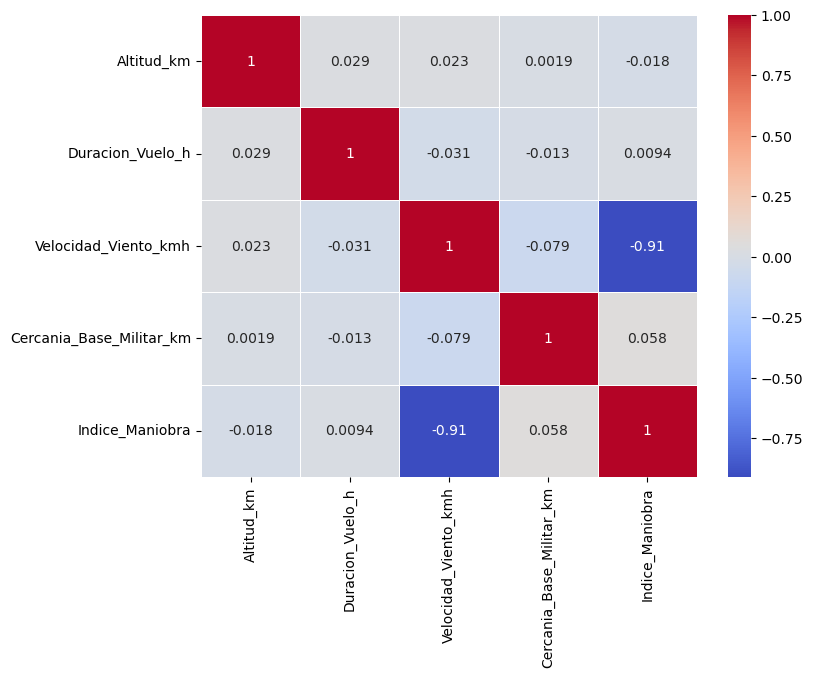

In [145]:
correlacion = data.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(correlacion,annot=True,cmap="coolwarm",linewidths=0.5) 